In [1]:
#Importing Python Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Sample _Superstore.csv", encoding="cp1252")
df_clean = df.copy()

In [3]:
#Get basic info/overview of the data

df.shape
df.head()
df.sample(5)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [4]:
#Data Cleaning

In [5]:
#1. Check for Missing Values
missing = pd.DataFrame({
    "Missing Count" : df.isnull().sum(),
    "Missing %" : (df.isnull().sum()/len(df))*100
})
missing = missing[missing["Missing Count"]>0] #To get cols who have missing values

print("No missing values found" if missing.empty else missing)

No missing values found


In [6]:
#2. Check for Duplicate Rows

duplicates = df.duplicated().sum()

if duplicates>0:
    duplicate_rows = pd.DataFrame(df[df.duplicated()])
    print(duplicate_rows)
else:
    print("No Duplicate rows found!")

No Duplicate rows found!


In [7]:
#3. Check data types eg. amount should int, not string, else convert it to int.

df_clean["Order Date"] = pd.to_datetime(df_clean["Order Date"])
df_clean["Ship Date"] = pd.to_datetime(df_clean["Ship Date"])

In [8]:
#4. Check for unique values in categorical columns to check for spelling inconsistencies (West & WEST)

for col in df_clean.select_dtypes(include="object"):
    print("*"*125)
    print(f"Column: {col}")
    print(f"Total unique Values in the column: {df_clean[col].nunique()}")
    print(df_clean[col].value_counts()) #Prints all the unique values with their frequency
#Very useful to understand the data profiles

*****************************************************************************************************************************
Column: Order ID
Total unique Values in the column: 5009
Order ID
CA-2017-100111    14
CA-2017-157987    12
CA-2016-165330    11
US-2016-108504    11
CA-2015-131338    10
                  ..
CA-2016-157259     1
CA-2017-107986     1
US-2015-112508     1
US-2016-126844     1
CA-2017-119914     1
Name: count, Length: 5009, dtype: int64
*****************************************************************************************************************************
Column: Ship Mode
Total unique Values in the column: 4
Ship Mode
Standard Class    5968
Second Class      1945
First Class       1538
Same Day           543
Name: count, dtype: int64
*****************************************************************************************************************************
Column: Customer ID
Total unique Values in the column: 793
Customer ID
WB-21850    37
JL-15835    34
M

In [9]:
#5. Get Numerical Summary

df_clean.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


Text(0.5, 1.0, 'Profit')

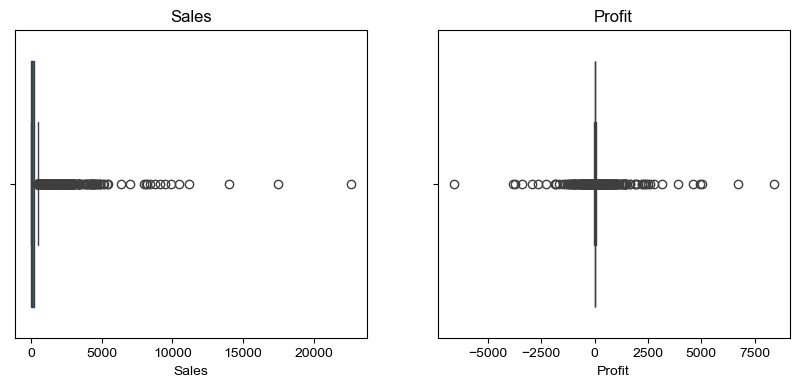

In [10]:
#6. Look for outliers (Because outliers need investigation)

fig, ax = plt.subplots(1,2, figsize = (10,4))

sns.set_theme(style="darkgrid")

sns.boxplot(
    data = df_clean,
    x = "Sales",
    ax = ax[0]
)
ax[0].set_title("Sales")

sns.boxplot(
    data = df_clean,
    x = "Profit",
    ax = ax[1]
)
ax[1].set_title("Profit")


In [11]:
#Fix column names & column data with trailing spaces

df_clean.columns = df_clean.columns.str.strip() #Fixed column names

for col in df_clean.select_dtypes(include="object"):
    df_clean[col] = df_clean[col].str.strip() #Fixed the column data
    

In [12]:
df.head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714


In [13]:
#EDA (Exploratory Data Analysis)

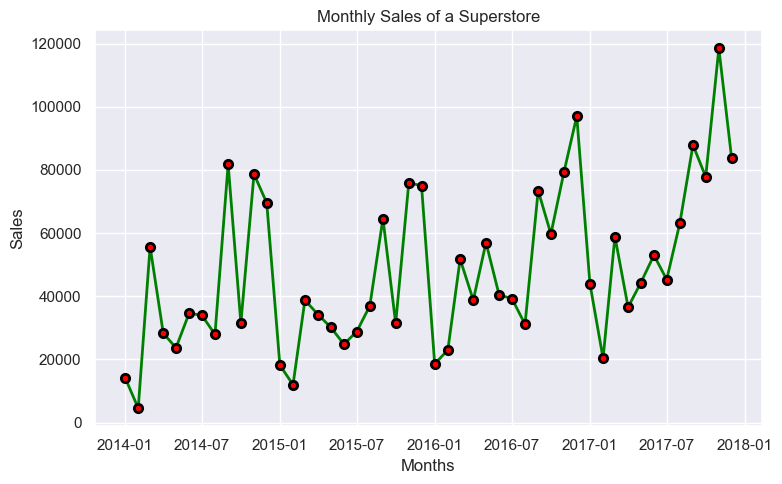

In [14]:
#1. Monthly sales
months = df_clean["Order Date"].dt.to_period("M") #it converts 2026-11-08 & 2026-11-15 to 2026-11 Here "M"=Months, then "Q"=Quarter, "W"=Week

monthly_sales = df_clean.groupby(months)["Sales"].sum().reset_index() #Previos idx = Order Date, Now id becomes 0,1,2... and Order Date becomes a column
monthly_sales["Order Date"] = monthly_sales["Order Date"].dt.to_timestamp() #Change the dtype from Preriod[M] to datetime64[ns]

sns.set_theme(style="darkgrid")
fig, ax = plt.subplots(figsize=(8,5))

sns.lineplot(
    data = monthly_sales,
    x = "Order Date",
    y = "Sales",
    linewidth = 2,
    color = "green",
    marker = "o",
    mfc = "red",
    mec = "black",
    mew = 2,
    ax = ax
)

ax.set_xlabel("Months")
ax.set_ylabel("Sales")
ax.set_title("Monthly Sales of a Superstore")
fig.tight_layout()

plt.show()

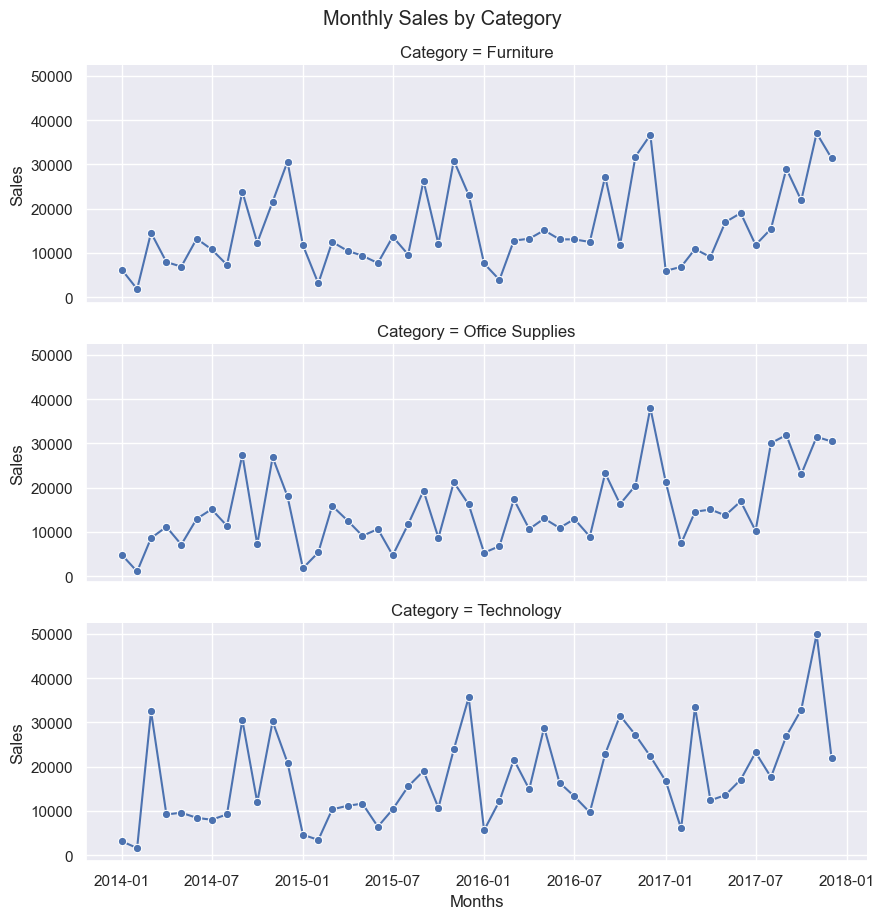

In [15]:
#2. Monthly Sales on the basis of product categories

months = df_clean["Order Date"].dt.to_period("M")

monthly_sales = df_clean.groupby([months, "Category"])["Sales"].sum().reset_index()
monthly_sales["Order Date"] = monthly_sales["Order Date"].dt.to_timestamp()

g = sns.relplot(
    data=monthly_sales,
    x="Order Date",
    y="Sales",
    col="Category",
    kind="line",
    marker="o",
    col_wrap=1,
    height=3,
    aspect=3
)

g.set_axis_labels("Months", "Sales")
g.figure.suptitle("Monthly Sales by Category", y=1.02)

plt.show()


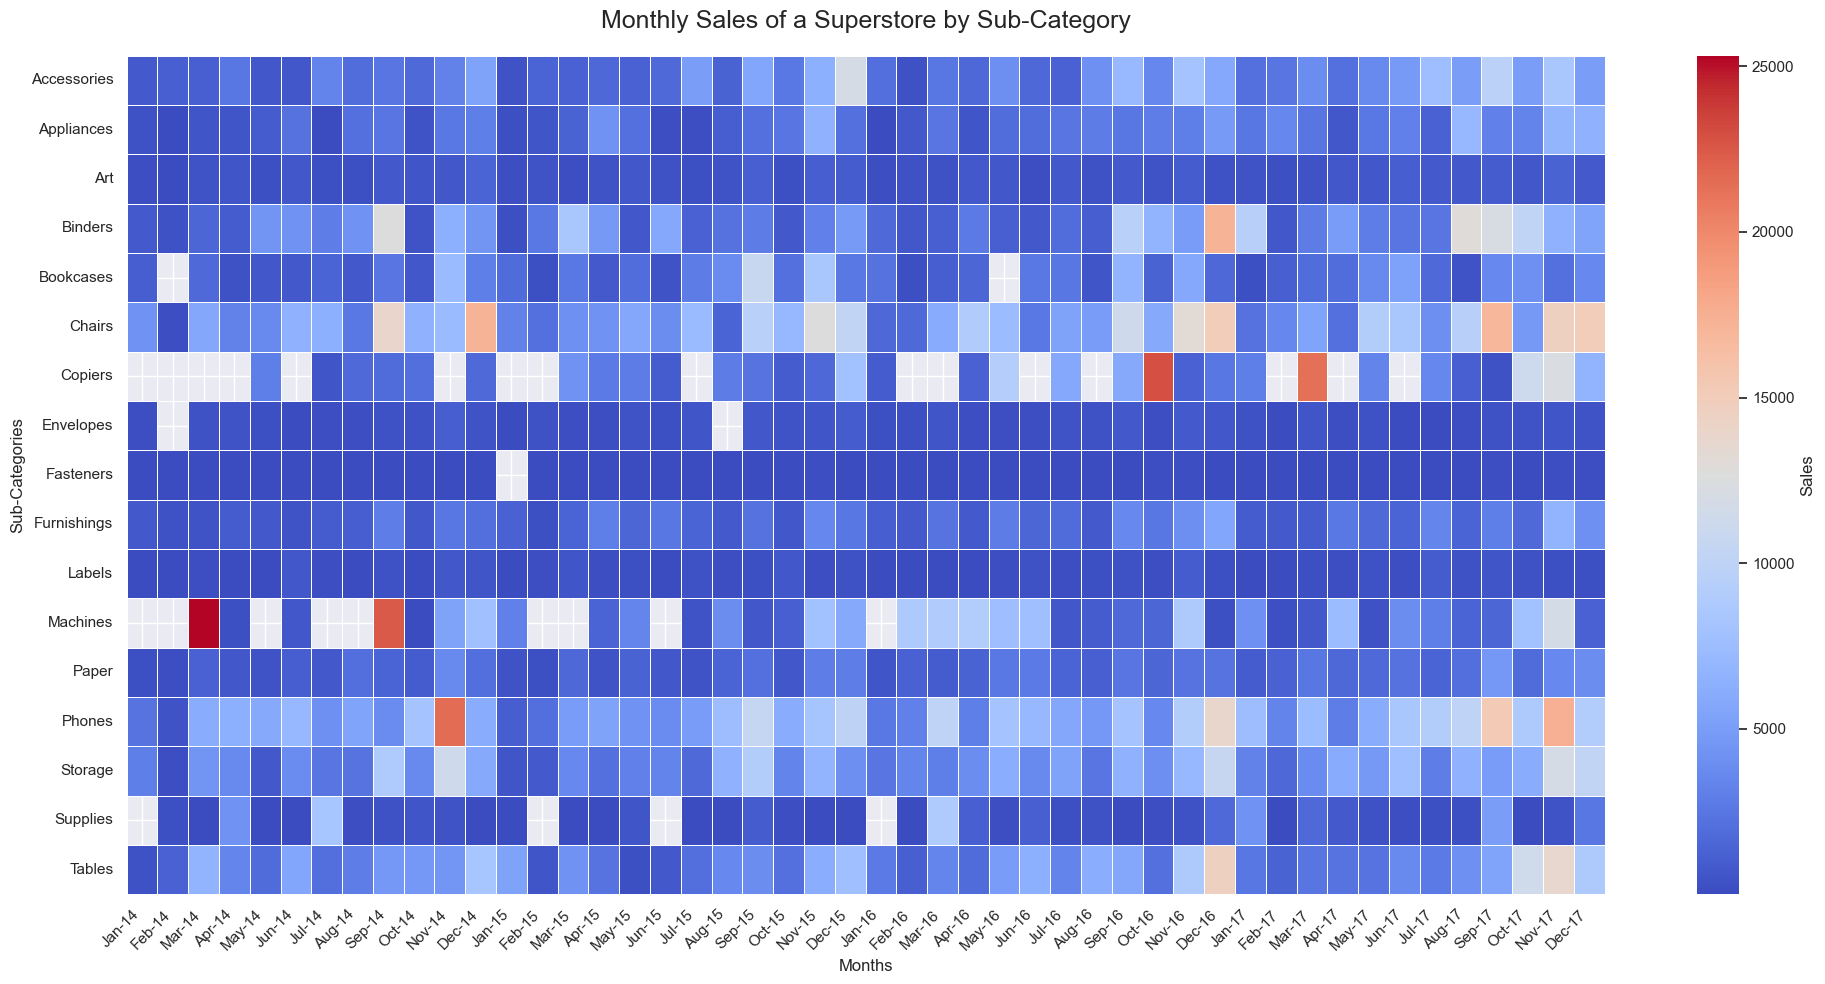

In [16]:
#3. Monthly Sales on the basis of product sub-categories

months = df_clean["Order Date"].dt.to_period("M")

monthly_sales = df_clean.groupby([months, "Sub-Category"])["Sales"].sum().reset_index()
monthly_sales["Order Date"] = monthly_sales["Order Date"].dt.to_timestamp()

pivot = monthly_sales.pivot_table(
    index = "Sub-Category",
    columns = "Order Date",
    values = "Sales",
    aggfunc = "sum",
)

pivot.columns = pivot.columns.strftime("%b-%y") #Jan-14, Feb-14... etc

sns.set_theme(style="darkgrid")

fig, ax = plt.subplots(figsize=(20,10))
sns.heatmap(
    data = pivot,
    cmap = "coolwarm",
    linecolor = "white",
    linewidth = 0.5,
    cbar_kws = {"label": "Sales"},
    ax = ax
)

plt.xticks(rotation = 45, ha = "right")
ax.set_xlabel("Months", fontsize = 12)
ax.set_ylabel("Sub-Categories", fontsize = 12)
ax.set_title("Monthly Sales of a Superstore by Sub-Category", fontsize = 18, pad = 20)
fig.tight_layout()

plt.show()

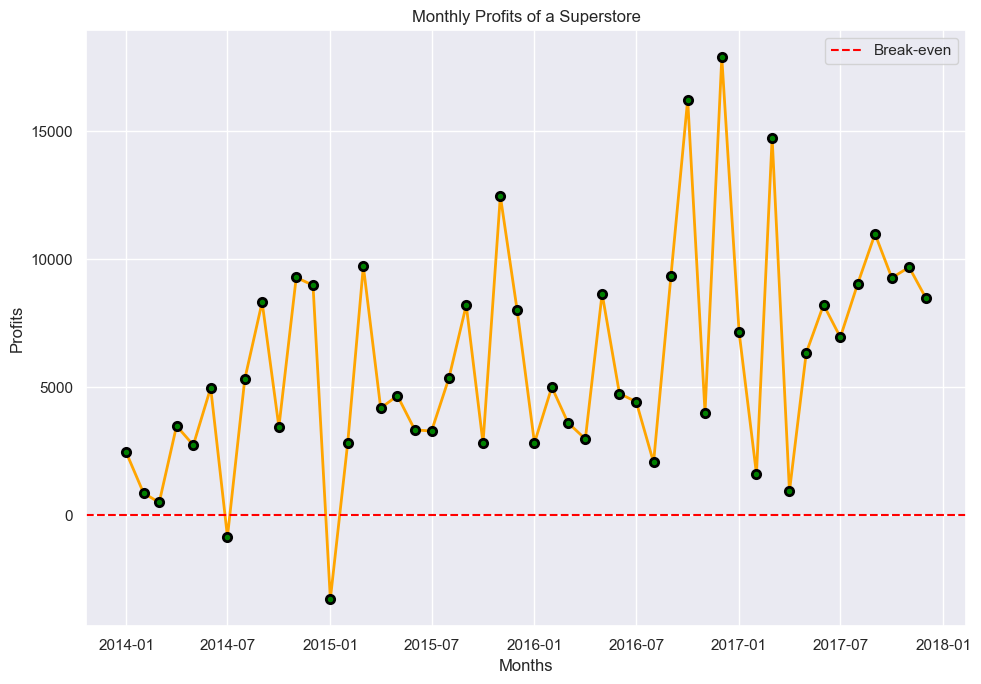

In [17]:
#4. Monthly profit from sales

months = df_clean["Order Date"].dt.to_period("M")

monthly_profit = df_clean.groupby(months)["Profit"].sum().reset_index()
monthly_profit["Order Date"] = monthly_profit["Order Date"].dt.to_timestamp()

sns.set_theme(style="darkgrid")

fig, ax = plt.subplots(figsize=(10,7))

sns.lineplot(
    data = monthly_profit,
    x = "Order Date",
    y = "Profit",
    color = "orange",
    linewidth = 2,
    marker = "o",
    mfc = "green",
    mec = "black",
    mew = 2,
    ax = ax
)

ax.axhline(y=0, color="red", linestyle="--", label="Break-even")
ax.legend()

ax.set_xlabel("Months")
ax.set_ylabel("Profits")
ax.set_title("Monthly Profits of a Superstore")

fig.tight_layout()
plt.show()

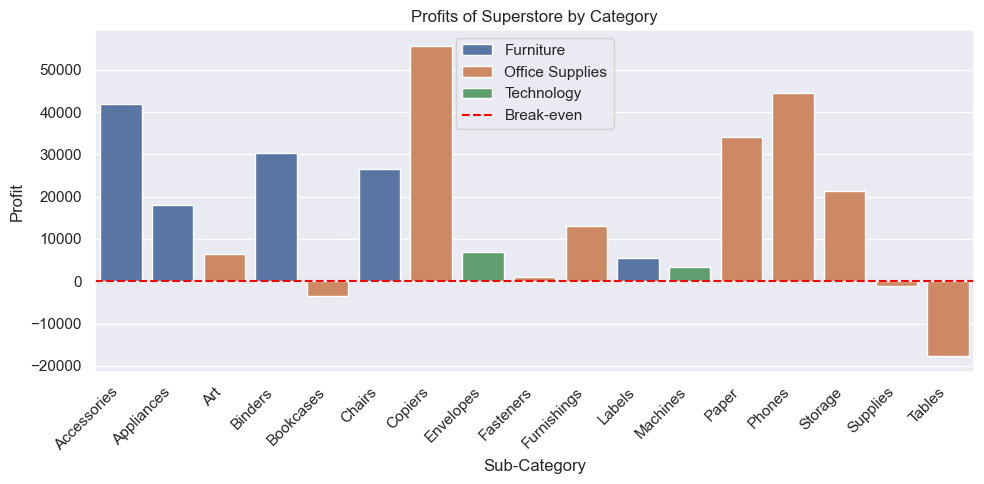

In [18]:
#5. Analyse the profit by category & sub-category

profit = df_clean.groupby("Sub-Category")["Profit"].sum().reset_index()

sns.set_theme(style="darkgrid")

fig, ax = plt.subplots(figsize=(10,5))
sns.barplot(
    data = profit,
    x = "Sub-Category",
    y = "Profit",
    hue = df_clean["Category"],
    ax = ax
)

ax.axhline(y=0, color="red", linestyle="--", label="Break-even")
ax.legend()
plt.xticks(rotation = 45, ha = "right")
ax.set_title("Profits of Superstore by Category")

fig.tight_layout()
plt.show()

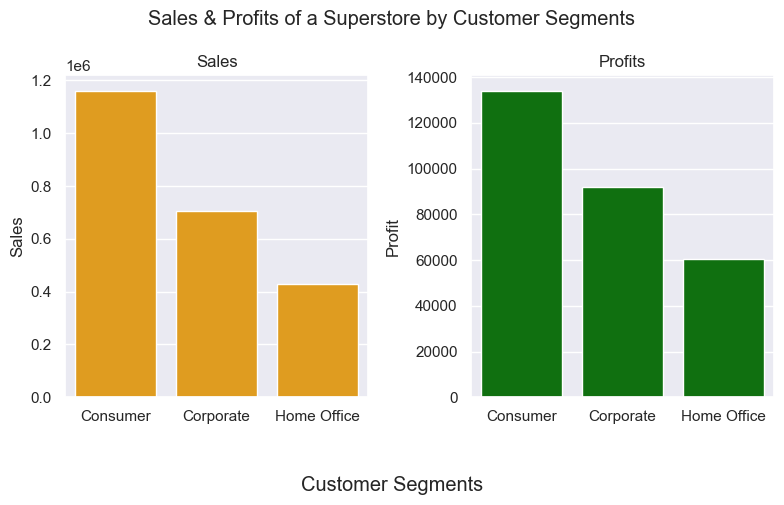

In [19]:
#6. Analyse the Sales & Profit by Customer Segment

customer_sales = df_clean.groupby("Segment")["Sales"].sum().reset_index()
customer_profits = df_clean.groupby("Segment")["Profit"].sum().reset_index()

sns.set_theme(style="darkgrid")

fig, ax = plt.subplots(1,2, figsize=(8,5))

sns.barplot(
    data = customer_sales,
    x = "Segment",
    y = "Sales",
    color = "orange",
    ax = ax[0]
)
ax[0].set_xlabel(" ")
ax[0].set_title("Sales")

sns.barplot(
    data = customer_profits,
    x = "Segment",
    y = "Profit",
    color = "green",
    ax = ax[1]
)
ax[1].set_xlabel(" ")
ax[1].set_title("Profits")

fig.supxlabel("Customer Segments")
fig.suptitle("Sales & Profits of a Superstore by Customer Segments")
fig.tight_layout()
plt.show()

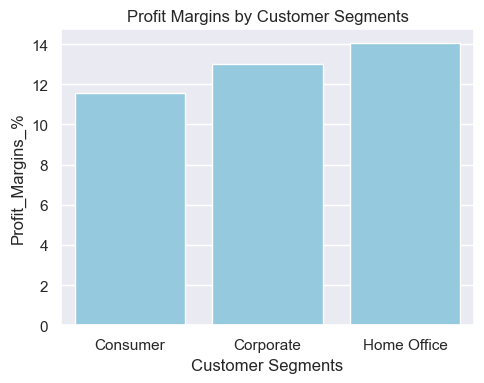

In [20]:
#7. Analyse Profit Margins

segment_ratio = df_clean.groupby("Segment").agg(
                                                Sales = ("Sales", "sum"),
                                                Profit = ("Profit", "sum")
).reset_index()
segment_ratio["Profit_Margins_%"] = (segment_ratio["Profit"]/segment_ratio["Sales"])*100

sns.set_theme(style="darkgrid")

fig, ax = plt.subplots(figsize=(5,4))
sns.barplot(
    data = segment_ratio,
    x = "Segment",
    y = "Profit_Margins_%",
    color = "skyblue",
    ax = ax
)

ax.set_xlabel("Customer Segments")
ax.set_title("Profit Margins by Customer Segments")

fig.tight_layout()
plt.show()